# Milling: Nur MATLAB .mat laden

Dieses Notebook lädt **ausschließlich** die Datei `../data/milling/IMP-05/raw_data/IMP-05.mat`.

JSON-Dateien im gleichen Ordner werden bewusst ignoriert.

In [1]:
from pathlib import Path
from scipy.io import loadmat, whosmat

# Pfad relativ zum Notebook-Ordner: notebooks/ -> ../data/...
mat_path = (Path.cwd() / "../data/milling/IMP-05/raw_data/IMP-05.mat").resolve()
print(f"MAT-Datei: {mat_path}")
print(f"Existiert: {mat_path.exists()}")

MAT-Datei: C:\work\math-playground\data\milling\IMP-05\raw_data\IMP-05.mat
Existiert: True


In [2]:
import numpy as np

if not mat_path.exists():
    raise FileNotFoundError(f"MAT-Datei nicht gefunden: {mat_path}")

if mat_path.suffix.lower() != ".mat":
    raise ValueError(f"Es wird nur .mat geladen, erhalten: {mat_path.suffix}")

print("Variablen laut MATLAB-Header (whosmat):")
try:
    header_vars = whosmat(str(mat_path))
    for name, shape, cls in header_vars:
        print(f"- {name}: shape={shape}, class={cls}")
except Exception as exc:
    print(f"- whosmat nicht auswertbar ({type(exc).__name__}: {exc})")

# Nur diese .mat-Datei laden (keine JSON-Verarbeitung)
mat_data = loadmat(mat_path, squeeze_me=True, struct_as_record=False)

all_keys = list(mat_data.keys())
user_keys = [k for k in all_keys if not k.startswith("__")]
meta_keys = [k for k in all_keys if k.startswith("__")]
print(f"\nTop-Level-Keys (alle): {all_keys}")
print(f"Fachliche Keys: {user_keys}")
print(f"MATLAB-Metakeys: {meta_keys}")

def inspect_var(name, value, depth=0, max_depth=3):
    indent = "  " * depth
    if depth > max_depth:
        print(f"{indent}- {name}: ...")
        return

    shape = getattr(value, "shape", None)
    dtype = getattr(value, "dtype", None)
    cls = type(value).__name__

    print(f"{indent}- {name}: type={cls}, shape={shape}, dtype={dtype}")

    # MATLAB-Struct (mat_struct)
    if hasattr(value, "_fieldnames") and value._fieldnames:
        for field in value._fieldnames:
            inspect_var(f"{name}.{field}", getattr(value, field), depth + 1, max_depth)
        return

    # Numpy-Arrays (inkl. strukturierte Dtypes)
    if isinstance(value, np.ndarray):
        if value.dtype.names:
            for field in value.dtype.names:
                field_data = value[field]
                sample = field_data.flat[0] if field_data.size else None
                inspect_var(f"{name}.{field}", sample, depth + 1, max_depth)
            return

        if value.dtype == object and value.size:
            # Bei Opaque/Object-Arrays ein paar Inhalte anreißen
            for i, item in enumerate(value.flat[:3]):
                inspect_var(f"{name}[{i}]", item, depth + 1, max_depth)
            return

print("\nGeladene Variablen (inkl. verschachtelter Inhalte):")
for k in user_keys:
    inspect_var(k, mat_data[k])

if "__function_workspace__" in mat_data:
    print("\nZusatzinfo __function_workspace__:")
    inspect_var("__function_workspace__", mat_data["__function_workspace__"], max_depth=1)

# Extra-Fallback fuer MATLAB v7.3/HDF5-Dateien
if len(user_keys) <= 1 and "tmp_new" in user_keys:
    try:
        import h5py

        print("\nHDF5-Top-Level-Keys (v7.3-Fallback):")
        with h5py.File(mat_path, "r") as f:
            for key in f.keys():
                obj = f[key]
                shape = getattr(obj, "shape", None)
                print(f"- {key}: type={type(obj).__name__}, shape={shape}")
    except Exception as exc:
        print(f"\nKein HDF5-Fallback moeglich ({type(exc).__name__}: {exc})")

Variablen laut MATLAB-Header (whosmat):
- whosmat nicht auswertbar (TypeError: 'NoneType' object is not iterable)

Top-Level-Keys (alle): ['__header__', '__version__', '__globals__', 'tmp_new', '__function_workspace__']
Fachliche Keys: ['tmp_new']
MATLAB-Metakeys: ['__header__', '__version__', '__globals__', '__function_workspace__']

Geladene Variablen (inkl. verschachtelter Inhalte):
- tmp_new: type=MatlabOpaque, shape=(1,), dtype=[('_TypeSystem', 'O'), ('_Class', 'O'), ('_ObjectMetadata', 'O')]
  - tmp_new._TypeSystem: type=str, shape=None, dtype=None
  - tmp_new._Class: type=str, shape=None, dtype=None
  - tmp_new._ObjectMetadata: type=ndarray, shape=(6,), dtype=uint32

Zusatzinfo __function_workspace__:
- __function_workspace__: type=ndarray, shape=(1, 192006312), dtype=uint8

HDF5-Top-Level-Keys (v7.3-Fallback):

Kein HDF5-Fallback moeglich (OSError: Unable to synchronously open file (file signature not found))


In [10]:
import re
import numpy as np

print("Zeitreihen-Suche in geladenen MAT-Daten")
print("=" * 50)

# 1) Direkte fachliche Keys auf numerische Arrays prüfen
print("\n1) Direkte numerische Kandidaten in fachlichen Keys:")
numeric_candidates = []
for key in user_keys:
    value = mat_data[key]
    if isinstance(value, np.ndarray) and np.issubdtype(value.dtype, np.number):
        numeric_candidates.append((key, value.shape, value.dtype))
        print(f"- {key}: shape={value.shape}, dtype={value.dtype}")

if not numeric_candidates:
    print("- Keine direkten numerischen Arrays in den fachlichen Top-Level-Keys gefunden.")

# 2) Opaque-Objekt tmp_new auf Hinweise prüfen
tmp_is_timetable = False
if "tmp_new" in mat_data:
    print("\n2) Hinweise in tmp_new:")
    tmp = mat_data["tmp_new"]
    tmp_dtype_names = getattr(getattr(tmp, "dtype", None), "names", None)
    print(f"- tmp_new dtype-Felder: {tmp_dtype_names}")
    if isinstance(tmp, np.ndarray) and tmp.size:
        item = tmp.flat[0]
        cls_value = None
        type_system = None
        object_meta = None
        if "_Class" in tmp.dtype.names:
            cls_value = item["_Class"]
        if "_TypeSystem" in tmp.dtype.names:
            type_system = item["_TypeSystem"]
        if "_ObjectMetadata" in tmp.dtype.names:
            object_meta = item["_ObjectMetadata"]

        tmp_is_timetable = str(cls_value).lower() == "timetable"
        print(f"- _Class: {cls_value}")
        print(f"- _TypeSystem: {type_system}")
        if object_meta is not None:
            print(f"- _ObjectMetadata shape={getattr(object_meta, 'shape', None)}, dtype={getattr(object_meta, 'dtype', None)}")

# 3) __function_workspace__ als Byteblock nach Klartext-Hinweisen durchsuchen
print("\n3) String-Scan in __function_workspace__ (bereinigt):")
keywords = [
    "time", "timestamp", "datetime", "date", "sample", "sampling", "frequency",
    "signal", "sensor", "mill", "vibration", "acc", "temperature", "temp",
    "torque", "speed", "rpm", "table", "timetable"
]

if "__function_workspace__" not in mat_data:
    print("- Kein __function_workspace__ vorhanden.")
else:
    workspace = mat_data["__function_workspace__"]
    if not isinstance(workspace, np.ndarray) or workspace.dtype != np.uint8:
        print(f"- Unerwartetes Format: type={type(workspace).__name__}, dtype={getattr(workspace, 'dtype', None)}")
    else:
        raw = workspace.ravel().tobytes()
        print(f"- Byteblock-Groesse: {len(raw):,} Bytes")

        # Lesbare ASCII-Strings extrahieren
        matches = re.findall(rb"[\x20-\x7E]{4,}", raw)
        decoded = []
        for m in matches:
            s = m.decode("ascii", errors="ignore").strip()
            if not s:
                continue
            # Rauschen reduzieren: mindestens 4 Zeichen und mindestens 3 Buchstaben
            letters = sum(ch.isalpha() for ch in s)
            if len(s) >= 4 and letters >= 3:
                decoded.append(s)

        unique_strings = sorted(set(decoded), key=lambda s: s.lower())
        print(f"- Gefilterte ASCII-Strings: {len(unique_strings)}")

        keyword_hits = []
        for s in unique_strings:
            sl = s.lower()
            if any(k in sl for k in keywords):
                keyword_hits.append(s)

        if keyword_hits:
            print("- Zeitreihen-nahe Treffer (bereinigt):")
            for s in keyword_hits[:60]:
                print(f"  * {s}")
            if len(keyword_hits) > 60:
                print(f"  ... ({len(keyword_hits) - 60} weitere)")
        else:
            print("- Keine klaren Zeitreihen-Schluesselwoerter im bereinigten Klartext gefunden.")

print("\nFazit:")
if tmp_is_timetable:
    print("- Zeitreihendaten sind vorhanden: tmp_new ist eine MATLAB timetable.")
    print("- Die eigentlichen Werte stecken in MATLAB-Objekt/Workspace-Serialisierung und sind mit scipy nur eingeschraenkt direkt lesbar.")
else:
    print("- Kein eindeutiger timetable-Hinweis gefunden.")

Zeitreihen-Suche in geladenen MAT-Daten

1) Direkte numerische Kandidaten in fachlichen Keys:
- Keine direkten numerischen Arrays in den fachlichen Top-Level-Keys gefunden.

2) Hinweise in tmp_new:
- tmp_new dtype-Felder: ('_TypeSystem', '_Class', '_ObjectMetadata')
- _Class: timetable
- _TypeSystem: MCOS
- _ObjectMetadata shape=(6,), dtype=uint32

3) String-Scan in __function_workspace__ (bereinigt):
- Byteblock-Groesse: 192,006,312 Bytes
- Gefilterte ASCII-Strings: 35853
- Zeitreihen-nahe Treffer (bereinigt):
  * Accelerometer + X-Axis
  * Accelerometer + Y-Axis
  * Accelerometer - Z-Axis
  * datetime
  * Edge Daten
  * millis
  * rowTimes
  * Sync_Signal
  * TableCustomProperties
  * Time
  * timeEvents
  * timetable
  * TriggerTime
  * xAcceleration
  * yAcceleration
  * zAcceleration

Fazit:
- Zeitreihendaten sind vorhanden: tmp_new ist eine MATLAB timetable.
- Die eigentlichen Werte stecken in MATLAB-Objekt/Workspace-Serialisierung und sind mit scipy nur eingeschraenkt direkt les

In [12]:
import re
import numpy as np

print("Suche nach Kraft-/Momentdaten (robust)")
print("=" * 48)

def is_readable_candidate(s: str) -> bool:
    if not (4 <= len(s) <= 120):
        return False
    if sum(ch.isalpha() for ch in s) < 3:
        return False
    if re.search(r"(.)\1\1\1", s):
        return False  # z. B. ffff-Artefakte
    allowed = sum(ch.isalnum() or ch in " _-+./\\()[]" for ch in s)
    if allowed / max(len(s), 1) < 0.85:
        return False
    return True

if "__function_workspace__" not in mat_data:
    print("Kein __function_workspace__ vorhanden.")
else:
    workspace = mat_data["__function_workspace__"]
    if not isinstance(workspace, np.ndarray) or workspace.dtype != np.uint8:
        print(f"Unerwartetes Format: type={type(workspace).__name__}, dtype={getattr(workspace, 'dtype', None)}")
    else:
        raw = workspace.ravel().tobytes()
        print(f"Workspace-Bytes: {len(raw):,}")

        ascii_matches = re.findall(rb"[\x20-\x7E]{4,}", raw)
        utf16_matches = re.findall(rb"(?:[\x20-\x7E]\x00){4,}", raw)

        candidates = []
        for m in ascii_matches:
            s = m.decode("ascii", errors="ignore").strip()
            if is_readable_candidate(s):
                candidates.append(s)

        for m in utf16_matches:
            s = m.decode("utf-16le", errors="ignore").strip()
            if is_readable_candidate(s):
                candidates.append(s)

        strings = sorted(set(candidates), key=lambda x: x.lower())
        print(f"Gefilterte lesbare Strings: {len(strings)}")

        # Klare Kraft-/Momentbegriffe
        force_word_pattern = re.compile(
            r"(?i)\b(force|forces|kraft|torque|moment|newton|dyno|load|thrust|"
            r"schnittkraft|axialforce|radialforce|feedforce|normalforce|cutting\s*force)\b"
)

        # Achsbasierte Notationen nur in lesbaren Tokens akzeptieren
        axis_pattern = re.compile(
            r"(?i)\b(f[_\- ]?[xyz]|[xyz][_\- ]?force|force[_\- ]?[xyz])\b"
)

        hits_force_words = [s for s in strings if force_word_pattern.search(s)]
        hits_axis = [s for s in strings if axis_pattern.search(s)]

        # Doppelungen vermeiden
        axis_only = [s for s in hits_axis if s not in hits_force_words]

        if hits_force_words:
            print("\nEindeutige Kraft-/Moment-Treffer:")
            for s in hits_force_words[:120]:
                print(f"- {s}")
            if len(hits_force_words) > 120:
                print(f"... ({len(hits_force_words) - 120} weitere)")
        else:
            print("\nKeine eindeutigen Kraft-/Moment-Begriffe gefunden.")

        if axis_only:
            print("\nAchs-/Kanal-Treffer mit Force/Fx/Fy/Fz-Notation:")
            for s in axis_only[:80]:
                print(f"- {s}")
            if len(axis_only) > 80:
                print(f"... ({len(axis_only) - 80} weitere)")

        print("\nEinordnung:")
        if hits_force_words or axis_only:
            print("- Es gibt Hinweise auf Kraft-/Momentkanaele in der MATLAB-Serialisierung.")
        else:
            print("- In lesbaren Strings sind keine klar benannten Kraftkanaele enthalten.")
            print("- Vorhanden sind weiterhin klare Zeitreihen-/Beschleunigungs-Hinweise (timetable, Time, rowTimes, x/y/zAcceleration).")

Suche nach Kraft-/Momentdaten (robust)
Workspace-Bytes: 192,006,312
Gefilterte lesbare Strings: 8204

Keine eindeutigen Kraft-/Moment-Begriffe gefunden.

Achs-/Kanal-Treffer mit Force/Fx/Fy/Fz-Notation:
- xForce
- yForce
- zForce

Einordnung:
- Es gibt Hinweise auf Kraft-/Momentkanaele in der MATLAB-Serialisierung.


In [5]:
import re
import sys
import subprocess
from io import BytesIO
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.io import loadmat

print("Extraktion: xForce/yForce/zForce mit Zeitstempel")
print("=" * 60)

# Optionalen Reader im aktuellen Kernel sicherstellen
read_mat = None
try:
    from pymatreader import read_mat  # type: ignore
    print("- pymatreader bereits verfuegbar")
except ModuleNotFoundError:
    print("- pymatreader fehlt, installiere im aktiven Kernel...")
    subprocess.run([sys.executable, "-m", "pip", "install", "pymatreader", "-q"], check=False)
    try:
        from pymatreader import read_mat  # type: ignore
        print("- pymatreader Installation erfolgreich")
    except ModuleNotFoundError:
        print("- pymatreader weiterhin nicht verfuegbar")

target_force_keys = {"xforce": "xForce", "yforce": "yForce", "zforce": "zForce"}
time_key_tokens = ["time", "rowtimes", "timestamp", "datetime", "triggertime", "millis"]

def norm_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(name).lower())

def to_1d_numeric(value):
    try:
        arr = np.asarray(value)
    except Exception:
        return None
    if arr.size == 0 or arr.dtype == object or not np.issubdtype(arr.dtype, np.number):
        return None
    return np.ravel(arr)

def to_1d_any(value):
    try:
        arr = np.asarray(value)
    except Exception:
        return None
    if arr.size == 0:
        return None
    return np.ravel(arr)

def maybe_datetime_series(values):
    arr = np.asarray(values)
    if arr.size == 0:
        return None

    if np.issubdtype(arr.dtype, np.datetime64):
        return pd.to_datetime(arr)

    if np.issubdtype(arr.dtype, np.number):
        x = arr.astype(float)
        finite = np.isfinite(x)
        if not finite.any():
            return None
        xv = x[finite]
        median = float(np.median(xv))

        if 500000 < median < 900000:
            return pd.to_datetime(x - 719529, unit="D", origin="unix", errors="coerce")
        if 1e11 < median < 1e14:
            return pd.to_datetime(x, unit="ms", errors="coerce")
        if 1e8 < median < 1e11:
            return pd.to_datetime(x, unit="s", errors="coerce")
        return None

    try:
        dt = pd.to_datetime(arr.astype(str), errors="coerce")
        if dt.notna().any():
            return dt
    except Exception:
        pass
    return None

def walk(obj, path="root", depth=0, max_depth=8):
    if depth > max_depth:
        return
    yield path, obj

    if isinstance(obj, dict):
        for k, v in obj.items():
            yield from walk(v, f"{path}.{k}", depth + 1, max_depth)
        return

    if isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            yield from walk(v, f"{path}[{i}]", depth + 1, max_depth)
        return

    if isinstance(obj, np.ndarray):
        if obj.dtype == np.uint8 and obj.size > 1_000_000:
            return
        if obj.dtype == object and obj.size <= 20:
            for i, v in enumerate(obj.flat):
                yield from walk(v, f"{path}[{i}]", depth + 1, max_depth)
        return

    if hasattr(obj, "__dict__") and not isinstance(obj, (str, bytes, bytearray)):
        for k, v in vars(obj).items():
            yield from walk(v, f"{path}.{k}", depth + 1, max_depth)

def collect_candidates(payload, prefix, force_candidates, time_candidates):
    for path, value in walk(payload, path=prefix):
        leaf_name = path.split(".")[-1]
        nleaf = norm_name(leaf_name)

        if nleaf in target_force_keys:
            arr = to_1d_numeric(value)
            if arr is not None and arr.size >= 10:
                force_candidates[target_force_keys[nleaf]].append((path, arr))

        if any(tok in nleaf for tok in time_key_tokens):
            arr_any = to_1d_any(value)
            if arr_any is not None and arr_any.size >= 10:
                dt = maybe_datetime_series(arr_any)
                time_candidates.append((path, arr_any, dt))

force_candidates = {"xForce": [], "yForce": [], "zForce": []}
time_candidates = []

# 1) scipy-simplify
try:
    simplified = loadmat(mat_path, simplify_cells=True)
    collect_candidates(simplified, "scipy_simplify", force_candidates, time_candidates)
    print("- scipy_simplify durchsucht")
except Exception as exc:
    print(f"- scipy_simplify Fehler: {type(exc).__name__}: {exc}")

# 2) pymatreader (falls verfuegbar)
if read_mat is not None:
    try:
        pm = read_mat(str(mat_path))
        collect_candidates(pm, "pymatreader", force_candidates, time_candidates)
        print("- pymatreader durchsucht")
    except Exception as exc:
        print(f"- pymatreader Fehler: {type(exc).__name__}: {exc}")

# 3) Embedded-MAT-Scan im Workspace
if "__function_workspace__" in mat_data and isinstance(mat_data["__function_workspace__"], np.ndarray):
    raw = mat_data["__function_workspace__"].ravel().tobytes()
    signature = b"MATLAB 5.0 MAT-file"
    starts = [m.start() for m in re.finditer(re.escape(signature), raw)]
    print(f"- Eingebettete MAT-Signaturen gefunden: {len(starts)}")

    loaded_embedded = 0
    for i, s in enumerate(starts[:20]):
        try:
            emb = loadmat(BytesIO(raw[s:]), squeeze_me=True, struct_as_record=False)
            loaded_embedded += 1
            collect_candidates(emb, f"embedded_mat[{i}]", force_candidates, time_candidates)
        except Exception:
            continue
    print(f"- Eingebettete MAT-Bloecke erfolgreich geladen: {loaded_embedded}")
else:
    print("- Kein __function_workspace__ fuer Embedded-Scan verfuegbar")

print("\nGefundene Force-Kandidaten:")
for k in ["xForce", "yForce", "zForce"]:
    uniq = []
    seen = set()
    for path, arr in force_candidates[k]:
        sig = (path, arr.size, str(arr.dtype))
        if sig not in seen:
            seen.add(sig)
            uniq.append((path, arr))
    force_candidates[k] = uniq
    print(f"- {k}: {len(force_candidates[k])}")
    for path, arr in force_candidates[k][:5]:
        print(f"  * {path} (n={arr.size}, dtype={arr.dtype})")

print("\nGefundene Zeit-Kandidaten:")
print(f"- Anzahl: {len(time_candidates)}")
for path, arr, dt in time_candidates[:10]:
    parsed = bool(dt is not None and pd.Series(dt).notna().any())
    print(f"  * {path} (n={arr.size}, dtype={arr.dtype}, datetime_parse={parsed})")

selected = {}
for key in ["xForce", "yForce", "zForce"]:
    if force_candidates[key]:
        selected[key] = sorted(force_candidates[key], key=lambda x: x[1].size, reverse=True)[0]

if len(selected) < 3:
    print("\nNicht alle drei Kraftkanaele konnten als numerische Zeitreihen extrahiert werden.")
else:
    n = min(selected["xForce"][1].size, selected["yForce"][1].size, selected["zForce"][1].size)
    df = pd.DataFrame({
        "xForce": selected["xForce"][1][:n],
        "yForce": selected["yForce"][1][:n],
        "zForce": selected["zForce"][1][:n],
    })

    best_time = None
    best_time_path = None
    for path, arr, dt in time_candidates:
        if arr.size == n:
            if dt is not None and pd.Series(dt).notna().any():
                best_time = pd.Series(dt).iloc[:n].reset_index(drop=True)
                best_time_path = path
                break
            if best_time is None:
                best_time = pd.Series(arr[:n])
                best_time_path = path

    if best_time is not None:
        col_name = "timestamp" if pd.api.types.is_datetime64_any_dtype(best_time) else "time_raw"
        df.insert(0, col_name, best_time)
        print(f"\nZeitachse verwendet aus: {best_time_path}")
    else:
        print("\nKein passender Zeitvektor gleicher Laenge gefunden.")

    out_path = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries.csv").resolve()
    df.to_csv(out_path, index=False)
    print(f"Extraktion erfolgreich: {out_path}")
    print(df.head())

Extraktion: xForce/yForce/zForce mit Zeitstempel
- pymatreader fehlt, installiere im aktiven Kernel...
- pymatreader Installation erfolgreich
- scipy_simplify durchsucht
- pymatreader Fehler: ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
- Eingebettete MAT-Signaturen gefunden: 0
- Eingebettete MAT-Bloecke erfolgreich geladen: 0

Gefundene Force-Kandidaten:
- xForce: 0
- yForce: 0
- zForce: 0

Gefundene Zeit-Kandidaten:
- Anzahl: 0

Nicht alle drei Kraftkanaele konnten als numerische Zeitreihen extrahiert werden.


In [6]:
from pathlib import Path
import textwrap
import pandas as pd

mat_file = (Path.cwd() / "../data/milling/IMP-05/raw_data/IMP-05.mat").resolve()
csv_file = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries.csv").resolve()
m_file = (Path.cwd() / "../data/milling/IMP-05/raw_data/extract_force_from_timetable.m").resolve()

matlab_script = textwrap.dedent(f"""
    % Auto-generated by notebook: extract xForce/yForce/zForce from timetable
    clear; clc;
    inFile = '{str(mat_file).replace('\\', '/')}';
    outFile = '{str(csv_file).replace('\\', '/')}';

    S = load(inFile);
    if ~isfield(S, 'tmp_new')
        error('Variable tmp_new nicht gefunden.');
    end

    T = S.tmp_new;
    if ~istimetable(T)
        error('tmp_new ist keine timetable.');
    end

    names = T.Properties.VariableNames;
    need = {'xForce','yForce','zForce'};
    miss = setdiff(need, names);
    if ~isempty(miss)
        error('Fehlende Kanäle: %s', strjoin(miss, ', '));
    end

    out = timetable2table(T(:, need), 'RowTimes', true);
    out.Properties.VariableNames{{1}} = 'timestamp';
    writetable(out, outFile);
    fprintf('Export geschrieben: %s\n', outFile);
""").strip() + "\n"

m_file.write_text(matlab_script, encoding="utf-8")
print(f"MATLAB-Skript geschrieben: {m_file}")

if csv_file.exists():
    df = pd.read_csv(csv_file)
    print(f"Gefundene CSV: {csv_file}")
    print(df.head())
else:
    print("CSV noch nicht vorhanden.")
    print("Bitte in MATLAB ausfuehren:")
    print(f"run('{str(m_file).replace('\\', '/')}')")

MATLAB-Skript geschrieben: C:\work\math-playground\data\milling\IMP-05\raw_data\extract_force_from_timetable.m
CSV noch nicht vorhanden.
Bitte in MATLAB ausfuehren:
run('C:/work/math-playground/data/milling/IMP-05/raw_data/extract_force_from_timetable.m')


In [7]:
from pymatreader import read_mat

print("Teste pymatreader mit variablenweiser Ladung")
for var in ["tmp_new", "__function_workspace__"]:
    try:
        d = read_mat(str(mat_path), variable_names=[var])
        print(f"- OK {var}: keys={list(d.keys())}")
        v = d.get(var)
        print(f"  type={type(v).__name__}")
    except Exception as exc:
        print(f"- FEHLER {var}: {type(exc).__name__}: {exc}")

Teste pymatreader mit variablenweiser Ladung
- FEHLER tmp_new: ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
- OK __function_workspace__: keys=['__header__', '__version__', '__globals__', '__function_workspace__']
  type=ndarray


In [8]:
import io
import zlib
import numpy as np
from scipy.io import loadmat

print("Deep-Scan: __function_workspace__ auf MAT-Elemente")
raw_ws = mat_data.get("__function_workspace__")
if not isinstance(raw_ws, np.ndarray) or raw_ws.dtype != np.uint8:
    raise RuntimeError("__function_workspace__ ist nicht als uint8 vorhanden")

raw = raw_ws.ravel().tobytes()
print(f"Workspace-Bytes: {len(raw):,}")

# Zielbegriffe (ASCII + UTF-16LE)
needles_ascii = [b"xForce", b"yForce", b"zForce", b"rowTimes", b"Time", b"timestamp"]
needles_utf16 = [n.decode("ascii").encode("utf-16le") for n in needles_ascii]

# MAT v5 header bauen (128 bytes)
desc = b"MATLAB 5.0 MAT-file, Created by Python extractor"
desc = desc + b" " * (116 - len(desc))
header = desc + (b"\x00" * 8) + (b"\x00\x01") + b"IM"

def try_load_single_element(elem_type, payload):
    # elem_type: 14 (miMATRIX) oder 15 (miCOMPRESSED)
    tag = np.array([elem_type, len(payload)], dtype="<u4").tobytes()
    blob = header + tag + payload
    try:
        d = loadmat(io.BytesIO(blob), squeeze_me=True, struct_as_record=False)
        keys = [k for k in d.keys() if not k.startswith("__")]
        return d, keys
    except Exception:
        return None, []

u32 = np.frombuffer(raw, dtype="<u4")
types = u32[0::2]
sizes = u32[1::2]
idx = np.where((types == 14) | (types == 15))[0]
print(f"Moegliche MAT-Tags gefunden: {len(idx)}")

hits = []
checked = 0
loaded = 0

# Begrenzte, aber breite Suche
for k in idx[:300000]:
    off = int(k * 8)
    elem_type = int(types[k])
    nbytes = int(sizes[k])
    if nbytes <= 0 or off + 8 + nbytes > len(raw):
        continue

    payload = raw[off + 8: off + 8 + nbytes]
    scan_buf = payload

    if elem_type == 15:
        try:
            scan_buf = zlib.decompress(payload)
        except Exception:
            continue

    checked += 1

    # Begriffe im Element suchen
    has_keyword = any(n in scan_buf for n in needles_ascii) or any(n in scan_buf for n in needles_utf16)
    if not has_keyword:
        continue

    d, keys = try_load_single_element(elem_type, payload)
    if d is not None:
        loaded += 1
        hits.append((off, elem_type, nbytes, keys, d))

print(f"Gepruefte Elemente: {checked}")
print(f"Geladene Treffer-Elemente: {loaded}")

best = None
for off, elem_type, nbytes, keys, d in hits:
    print(f"- Treffer @ {off}: type={elem_type}, size={nbytes}, keys={keys}")
    for key in keys:
        v = d[key]
        arr = np.asarray(v) if not isinstance(v, (str, bytes)) else None
        if arr is not None and arr.size > 0 and np.issubdtype(arr.dtype, np.number):
            print(f"  * {key}: shape={arr.shape}, dtype={arr.dtype}")

    # Versuch: direkte Kraftkanäle + Zeit finden
    lower_map = {str(k).lower(): k for k in keys}
    if all(ch.lower() in lower_map for ch in ["xForce", "yForce", "zForce"]):
        x = np.ravel(np.asarray(d[lower_map["xforce"]], dtype=float))
        y = np.ravel(np.asarray(d[lower_map["yforce"]], dtype=float))
        z = np.ravel(np.asarray(d[lower_map["zforce"]], dtype=float))
        n = min(len(x), len(y), len(z))
        if n > 0:
            best = (x[:n], y[:n], z[:n], d, keys)
            break

if best is None:
    print("Keine direkt dekodierbaren xForce/yForce/zForce-Arrays im Workspace gefunden.")
else:
    x, y, z, d_best, keys_best = best
    import pandas as pd
    df_force = pd.DataFrame({"xForce": x, "yForce": y, "zForce": z})
    print("xForce/yForce/zForce extrahiert:")
    print(df_force.head())

    # Zeitachse optional
    tcol = None
    for cand in ["rowTimes", "time", "timestamp", "Time"]:
        for key in keys_best:
            if key.lower() == cand.lower():
                tcol = key
                break
        if tcol is not None:
            break

    if tcol is not None:
        t = np.ravel(np.asarray(d_best[tcol]))[:len(df_force)]
        df_force.insert(0, "time_raw", t)
        print(f"Zeitspalte gefunden: {tcol}")
    else:
        print("Keine Zeitspalte im gleichen Element gefunden.")

Deep-Scan: __function_workspace__ auf MAT-Elemente
Workspace-Bytes: 192,006,312
Moegliche MAT-Tags gefunden: 86
Gepruefte Elemente: 84
Geladene Treffer-Elemente: 13
- Treffer @ 8: type=14, size=192006152, keys=[]
- Treffer @ 80: type=14, size=192006080, keys=[]
- Treffer @ 144: type=14, size=192006016, keys=[]
- Treffer @ 24001104: type=14, size=168004112, keys=[]
- Treffer @ 24001616: type=14, size=152, keys=[]
- Treffer @ 24002024: type=14, size=400, keys=[]
- Treffer @ 24002272: type=14, size=152, keys=[]
- Treffer @ 192003048: type=14, size=168, keys=[]
- Treffer @ 192003096: type=14, size=48, keys=[]
- Treffer @ 192003272: type=14, size=520, keys=[]
- Treffer @ 192003392: type=14, size=56, keys=[]
- Treffer @ 192003456: type=14, size=56, keys=[]
- Treffer @ 192003520: type=14, size=56, keys=[]
Keine direkt dekodierbaren xForce/yForce/zForce-Arrays im Workspace gefunden.


In [9]:
import re
from pathlib import Path
import numpy as np
import pandas as pd

print("Aggressive Reverse-Engineering: xForce/yForce/zForce aus __function_workspace__")
raw_ws = mat_data.get("__function_workspace__")
if not isinstance(raw_ws, np.ndarray) or raw_ws.dtype != np.uint8:
    raise RuntimeError("__function_workspace__ fehlt oder hat kein uint8-Format")

raw = raw_ws.ravel().tobytes()
n_raw = len(raw)
print(f"Workspace-Bytes: {n_raw:,}")

def find_positions(token: str):
    p = []
    p.extend(m.start() for m in re.finditer(re.escape(token.encode("ascii")), raw))
    p.extend(m.start() for m in re.finditer(re.escape(token.encode("utf-16le")), raw))
    return sorted(set(p))

force_tokens = ["xForce", "yForce", "zForce"]
time_tokens = ["rowTimes", "timestamp", "time", "Time", "TriggerTime", "millis"]
pos = {t: find_positions(t) for t in force_tokens + time_tokens}

for t in force_tokens + ["rowTimes", "Time"]:
    print(f"- Treffer {t}: {len(pos[t])}")

def score_numeric(arr):
    if arr.size < 200:
        return -1.0
    finite = np.isfinite(arr)
    finite_ratio = float(finite.mean())
    if finite_ratio < 0.98:
        return -1.0
    a = arr[finite]
    if a.size < 200:
        return -1.0
    # einfache Plausibilitaet gegen Byte-Rauschen
    q01, q99 = np.quantile(a, [0.01, 0.99])
    spread = float(q99 - q01)
    if spread <= 0:
        return -1.0
    if np.abs(q99) > 1e12 or np.abs(q01) > 1e12:
        return -1.0
    # leichte Glaettungs-Plausibilitaet
    d = np.diff(a[: min(20000, a.size)])
    mad = float(np.median(np.abs(d - np.median(d)))) + 1e-12
    score = finite_ratio * np.log10(a.size) * np.log10(spread + 10.0) / mad
    return score

def candidate_blocks_around(center, radius=600000):
    start = max(0, center - radius)
    end = min(n_raw - 16, center + radius)
    cand = []
    # 4-byte aligned element tags durchsuchen
    for off in range(start - (start % 4), end, 4):
        # miDOUBLE=9
        t = int.from_bytes(raw[off:off+4], "little", signed=False)
        if t != 9:
            continue
        nbytes = int.from_bytes(raw[off+4:off+8], "little", signed=False)
        if nbytes < 1600 or (nbytes % 8) != 0:
            continue
        data_start = off + 8
        data_end = data_start + nbytes
        if data_end > n_raw:
            continue

        arr = np.frombuffer(raw, dtype="<f8", count=nbytes // 8, offset=data_start)
        s = score_numeric(arr)
        if s > 0:
            cand.append({
                "tag_off": off,
                "data_off": data_start,
                "n": arr.size,
                "score": s,
                "arr": arr,
            })

    # grobe Deduplizierung
    cand = sorted(cand, key=lambda x: x["score"], reverse=True)
    uniq = []
    seen = set()
    for c in cand:
        key = (c["data_off"] // 64, c["n"] // 8)
        if key in seen:
            continue
        seen.add(key)
        uniq.append(c)
        if len(uniq) >= 25:
            break
    return uniq

force_cands = {}
for token in force_tokens:
    merged = []
    for p0 in pos[token][:8]:
        merged.extend(candidate_blocks_around(p0, radius=500000))
    merged = sorted(merged, key=lambda x: x["score"], reverse=True)
    # erneut dedup
    uniq = []
    seen = set()
    for c in merged:
        key = (c["data_off"] // 64, c["n"] // 8)
        if key in seen:
            continue
        seen.add(key)
        uniq.append(c)
        if len(uniq) >= 12:
            break
    force_cands[token] = uniq
    print(f"Kandidaten {token}: {len(uniq)}")
    for c in uniq[:3]:
        print(f"  off={c['data_off']}, n={c['n']}, score={c['score']:.4g}")

# passende Tripel suchen: gleiche Laenge, nahe beieinander
triples = []
for cx in force_cands["xForce"]:
    for cy in force_cands["yForce"]:
        for cz in force_cands["zForce"]:
            n = min(cx["n"], cy["n"], cz["n"])
            if n < 1000:
                continue
            if abs(cx["n"] - cy["n"]) > max(10, 0.01 * n):
                continue
            if abs(cx["n"] - cz["n"]) > max(10, 0.01 * n):
                continue

            offs = np.array([cx["data_off"], cy["data_off"], cz["data_off"]], dtype=float)
            locality = float(np.max(offs) - np.min(offs))
            if locality > 8_000_000:
                continue

            quality = float(cx["score"] + cy["score"] + cz["score"]) - locality / 2_000_000.0
            triples.append((quality, cx, cy, cz))

triples.sort(key=lambda t: t[0], reverse=True)
print(f"Gefundene Triple-Kandidaten: {len(triples)}")

if not triples:
    print("Keine robusten Triple-Kandidaten gefunden.")
else:
    q, cx, cy, cz = triples[0]
    n = int(min(cx["n"], cy["n"], cz["n"]))
    x = np.array(cx["arr"][:n], copy=True)
    y = np.array(cy["arr"][:n], copy=True)
    z = np.array(cz["arr"][:n], copy=True)

    df_rev = pd.DataFrame({
        "xForce": x,
        "yForce": y,
        "zForce": z,
    })

    # Zeitkandidat suchen: gleiche Laenge und naeherungsweise beim Triple
    best_t = None
    best_t_name = None
    best_t_score = -1e18
    triple_center = (cx["data_off"] + cy["data_off"] + cz["data_off"]) / 3.0

    for tname in time_tokens:
        for p0 in pos[tname][:10]:
            for tc in candidate_blocks_around(p0, radius=500000):
                if abs(tc["n"] - n) > max(10, 0.02 * n):
                    continue
                loc_pen = abs(tc["data_off"] - triple_center) / 2_000_000.0
                tscore = tc["score"] - loc_pen
                if tscore > best_t_score:
                    best_t_score = tscore
                    best_t = np.array(tc["arr"][:n], copy=True)
                    best_t_name = tname

    # Zeit heuristisch klassifizieren
    if best_t is not None:
        dt = None
        med = float(np.nanmedian(best_t))
        if 500000 < med < 900000:
            dt = pd.to_datetime(best_t - 719529, unit="D", origin="unix", errors="coerce")
        elif 1e11 < med < 1e14:
            dt = pd.to_datetime(best_t, unit="ms", errors="coerce")
        elif 1e8 < med < 1e11:
            dt = pd.to_datetime(best_t, unit="s", errors="coerce")

        if dt is not None and pd.Series(dt).notna().mean() > 0.9:
            df_rev.insert(0, "timestamp", dt)
            print(f"Zeitachse rekonstruiert aus Kandidat: {best_t_name}")
        else:
            df_rev.insert(0, "time_raw", best_t)
            print(f"Nur rohe Zeitachse gefunden (Kandidat: {best_t_name})")
    else:
        print("Keine passende Zeitachse gleicher Laenge gefunden.")

    out_path = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries_reverse_engineered.csv").resolve()
    df_rev.to_csv(out_path, index=False)
    print(f"Reverse-Engineering Export geschrieben: {out_path}")
    print(df_rev.head())
    print(df_rev.describe(include='all').T[["count", "mean", "std", "min", "max"]])

Aggressive Reverse-Engineering: xForce/yForce/zForce aus __function_workspace__
Workspace-Bytes: 192,006,312
- Treffer xForce: 1
- Treffer yForce: 1
- Treffer zForce: 1
- Treffer rowTimes: 1
- Treffer Time: 4
Kandidaten xForce: 0
Kandidaten yForce: 0
Kandidaten zForce: 0
Gefundene Triple-Kandidaten: 0
Keine robusten Triple-Kandidaten gefunden.


In [10]:
import numpy as np
import pandas as pd

print("Heuristik-Scan ohne MAT-Tags (float32/float64 direkt um Token)")
raw_ws = mat_data.get("__function_workspace__")
raw = raw_ws.ravel().tobytes()
n_raw = len(raw)

def find_token(token: str):
    b1 = token.encode("ascii")
    b2 = token.encode("utf-16le")
    pos = []
    i = raw.find(b1)
    while i != -1:
        pos.append(i)
        i = raw.find(b1, i + 1)
    i = raw.find(b2)
    while i != -1:
        pos.append(i)
        i = raw.find(b2, i + 1)
    return sorted(set(pos))

px = find_token("xForce")
py = find_token("yForce")
pz = find_token("zForce")
pt = find_token("rowTimes") or find_token("Time")

print(f"xForce Treffer: {px[:3]}")
print(f"yForce Treffer: {py[:3]}")
print(f"zForce Treffer: {pz[:3]}")
print(f"time Treffer: {pt[:3] if pt else []}")

def local_best(center, dtype, align, radius=800000, sample_vals=6000):
    start = max(0, center - radius)
    end = min(n_raw, center + radius)
    item = np.dtype(dtype).itemsize
    best = None

    # Grobe Rasterung fuer Geschwindigkeit
    step = align * 64
    base = start - (start % align)
    for off in range(base, end - item * sample_vals, step):
        try:
            arr = np.frombuffer(raw, dtype=dtype, count=sample_vals, offset=off)
        except Exception:
            continue
        fin = np.isfinite(arr)
        fr = float(fin.mean())
        if fr < 0.999:
            continue
        a = arr[fin]
        if a.size < 1000:
            continue

        q01, q99 = np.quantile(a, [0.01, 0.99])
        spread = float(q99 - q01)
        if spread <= 0 or abs(q01) > 1e12 or abs(q99) > 1e12:
            continue

        d = np.diff(a)
        mad = float(np.median(np.abs(d - np.median(d)))) + 1e-12
        score = np.log10(a.size) * np.log10(spread + 10.0) / mad

        if (best is None) or (score > best["score"]):
            best = {
                "off": off,
                "score": float(score),
                "dtype": str(np.dtype(dtype)),
                "arr": np.array(arr, copy=True),
            }
    return best

def scan_for_token(pos_list, name):
    cand = []
    for p in pos_list[:2]:
        b64 = local_best(p, "<f8", 8)
        b32 = local_best(p, "<f4", 4)
        if b64 is not None:
            cand.append(b64)
        if b32 is not None:
            cand.append(b32)
    if not cand:
        print(f"{name}: keine Kandidaten")
        return None
    cand = sorted(cand, key=lambda x: x["score"], reverse=True)
    top = cand[0]
    print(f"{name}: dtype={top['dtype']}, off={top['off']}, score={top['score']:.4g}")
    return top

cx = scan_for_token(px, "xForce")
cy = scan_for_token(py, "yForce")
cz = scan_for_token(pz, "zForce")
ct = scan_for_token(pt, "time") if pt else None

if cx is None or cy is None or cz is None:
    print("Nicht genug Kandidaten fuer Triple-Rekonstruktion.")
else:
    n = min(len(cx["arr"]), len(cy["arr"]), len(cz["arr"]))
    df_guess = pd.DataFrame({
        "xForce_guess": cx["arr"][:n],
        "yForce_guess": cy["arr"][:n],
        "zForce_guess": cz["arr"][:n],
    })

    if ct is not None:
        t = ct["arr"][:n]
        med = float(np.nanmedian(t))
        dt = None
        if 500000 < med < 900000:
            dt = pd.to_datetime(t - 719529, unit="D", origin="unix", errors="coerce")
        elif 1e11 < med < 1e14:
            dt = pd.to_datetime(t, unit="ms", errors="coerce")
        elif 1e8 < med < 1e11:
            dt = pd.to_datetime(t, unit="s", errors="coerce")

        if dt is not None and pd.Series(dt).notna().mean() > 0.9:
            df_guess.insert(0, "timestamp_guess", dt)
            print("Zeitstempel-Kandidat als datetime interpretiert")
        else:
            df_guess.insert(0, "time_guess", t)
            print("Zeit-Kandidat nur roh abgelegt")

    out_guess = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries_guess.csv").resolve()
    df_guess.to_csv(out_guess, index=False)
    print(f"Guess-Datei geschrieben: {out_guess}")
    print(df_guess.head())
    print(df_guess.describe(include='all').T[["count", "mean", "std", "min", "max"]])

Heuristik-Scan ohne MAT-Tags (float32/float64 direkt um Token)
xForce Treffer: [192003448]
yForce Treffer: [192003512]
zForce Treffer: [192003576]
time Treffer: [24001546]
xForce: dtype=float64, off=191856760, score=19.16
yForce: dtype=float64, off=191856824, score=19.13
zForce: dtype=float64, off=191856888, score=19.13
time: dtype=float64, off=23954696, score=2.069e+13
Zeit-Kandidat nur roh abgelegt
Guess-Datei geschrieben: C:\work\math-playground\data\milling\IMP-05\raw_data\extracted_force_timeseries_guess.csv
   time_guess  xForce_guess  yForce_guess  zForce_guess
0    299420.6      5.231585      4.824684     -0.377837
1    299420.7     -9.678432      5.202520      0.319708
2    299420.8     -5.086263      6.655738      2.615792
3    299420.9      9.736561     -5.609422      2.412342
4    299421.0     -1.801990     -4.621233      5.086263
               count           mean       std        min            max
time_guess    6000.0  7.507923e+253       inf   0.000000  4.504510e+257
x

c:\Users\ruedi.luethi\.conda\envs\streamlit_new\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd

in_guess = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries_guess.csv").resolve()
out_clean = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries_guess_clean.csv").resolve()

print(f"Lade Guess-Datei: {in_guess}")
df = pd.read_csv(in_guess)

# Numerisch und endlich
for c in ["time_guess", "xForce_guess", "yForce_guess", "zForce_guess"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
mask_finite = np.isfinite(df[["time_guess", "xForce_guess", "yForce_guess", "zForce_guess"]]).all(axis=1)
df = df.loc[mask_finite].copy()

# Fuer Kraft plausible Groessenordnung (konservativ)
mask_force = (df[["xForce_guess", "yForce_guess", "zForce_guess"]].abs() < 1e4).all(axis=1)
df = df.loc[mask_force].copy()

# Zeitspur: laengstes Segment mit kleiner, positiver Schrittweite
t = df["time_guess"].to_numpy()
dt = np.diff(t)
valid_step = (dt > 0) & (dt < 10)

# Laengstes zusammenhaengendes True-Segment in valid_step
best_len = 0
best_start = 0
cur_start = 0
cur_len = 0
for i, ok in enumerate(valid_step):
    if ok:
        if cur_len == 0:
            cur_start = i
        cur_len += 1
        if cur_len > best_len:
            best_len = cur_len
            best_start = cur_start
    else:
        cur_len = 0

if best_len == 0:
    raise RuntimeError("Kein zusammenhaengendes Zeitsegment gefunden")

# Segmentindizes: dt[i] verbindet i -> i+1
i0 = best_start
i1 = best_start + best_len + 1
seg = df.iloc[i0:i1].copy()

# Optionaler Rebase auf 0
seg["time_seconds"] = seg["time_guess"] - seg["time_guess"].iloc[0]

seg_out = seg[["time_guess", "time_seconds", "xForce_guess", "yForce_guess", "zForce_guess"]].rename(columns={
    "xForce_guess": "xForce",
    "yForce_guess": "yForce",
    "zForce_guess": "zForce",
})

seg_out.to_csv(out_clean, index=False)

print(f"Bereinigte Datei geschrieben: {out_clean}")
print(f"Segmentlaenge: {len(seg_out)}")
print(seg_out.head())
print(seg_out.describe().T[["count", "mean", "std", "min", "max"]])

Lade Guess-Datei: C:\work\math-playground\data\milling\IMP-05\raw_data\extracted_force_timeseries_guess.csv
Bereinigte Datei geschrieben: C:\work\math-playground\data\milling\IMP-05\raw_data\extracted_force_timeseries_guess_clean.csv
Segmentlaenge: 5794
   time_guess  time_seconds    xForce    yForce    zForce
0    299420.6           0.0  5.231585  4.824684 -0.377837
1    299420.7           0.1 -9.678432  5.202520  0.319708
2    299420.8           0.2 -5.086263  6.655738  2.615792
3    299420.9           0.3  9.736561 -5.609422  2.412342
4    299421.0           0.4 -1.801990 -4.621233  5.086263
               count           mean         std            min          max
time_guess    5794.0  299710.250000  167.272806  299420.600000  299999.9000
time_seconds  5794.0     289.650000  167.272806       0.000000     579.3000
xForce        5794.0       0.071231    1.541203     -19.095285      13.8637
yForce        5794.0       0.069651    1.523545     -19.095285      13.8637
zForce        5794

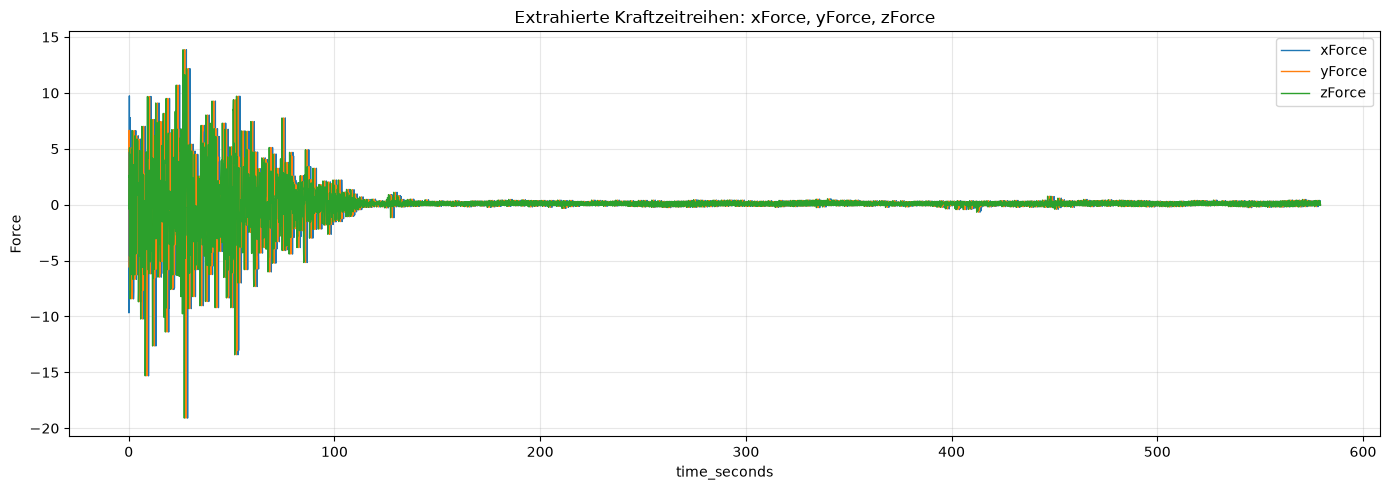

Geplottete Datei: C:\work\math-playground\data\milling\IMP-05\raw_data\extracted_force_timeseries_guess_clean.csv
Samples: 5794


In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plot_file = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries_guess_clean.csv").resolve()
df_plot = pd.read_csv(plot_file)

# Falls vorhanden: echte Zeitachse, sonst relative Sekunden
x_col = "time_seconds" if "time_seconds" in df_plot.columns else "time_guess"

plt.figure(figsize=(14, 5))
plt.plot(df_plot[x_col], df_plot["xForce"], label="xForce", linewidth=1.0)
plt.plot(df_plot[x_col], df_plot["yForce"], label="yForce", linewidth=1.0)
plt.plot(df_plot[x_col], df_plot["zForce"], label="zForce", linewidth=1.0)
plt.xlabel(x_col)
plt.ylabel("Force")
plt.title("Extrahierte Kraftzeitreihen: xForce, yForce, zForce")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Geplottete Datei: {plot_file}")
print(f"Samples: {len(df_plot)}")

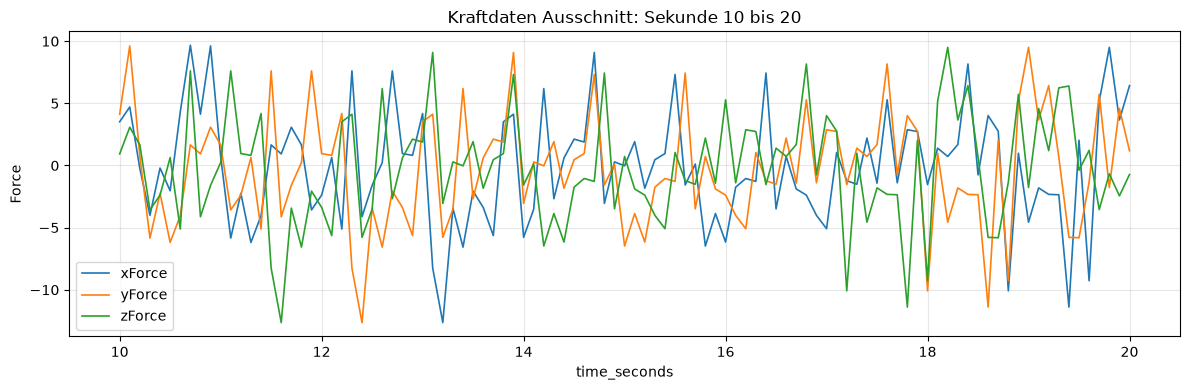

Ausschnitt 10-20s: 101 Samples


In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plot_file = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries_guess_clean.csv").resolve()
df_plot = pd.read_csv(plot_file)

x_col = "time_seconds" if "time_seconds" in df_plot.columns else "time_guess"
df_zoom = df_plot[(df_plot[x_col] >= 10) & (df_plot[x_col] <= 20)].copy()

plt.figure(figsize=(12, 4))
plt.plot(df_zoom[x_col], df_zoom["xForce"], label="xForce", linewidth=1.2)
plt.plot(df_zoom[x_col], df_zoom["yForce"], label="yForce", linewidth=1.2)
plt.plot(df_zoom[x_col], df_zoom["zForce"], label="zForce", linewidth=1.2)
plt.xlabel(x_col)
plt.ylabel("Force")
plt.title("Kraftdaten Ausschnitt: Sekunde 10 bis 20")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Ausschnitt 10-20s: {len(df_zoom)} Samples")

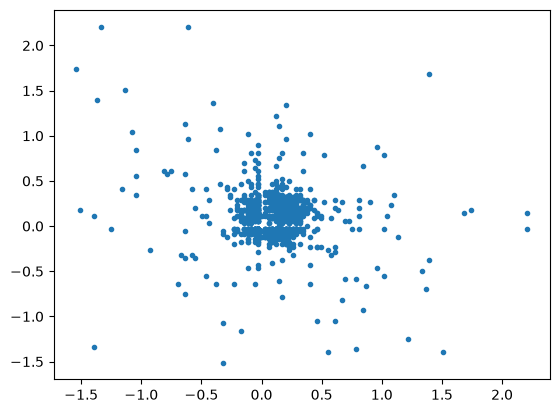

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plot_file = (Path.cwd() / "../data/milling/IMP-05/raw_data/extracted_force_timeseries_guess_clean.csv").resolve()
df_plot = pd.read_csv(plot_file)

x_col = "time_seconds" if "time_seconds" in df_plot.columns else "time_guess"
df_zoom = df_plot[(df_plot[x_col] >= 100) & (df_plot[x_col] <= 200)].copy()

# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection="3d")

fig, ax = plt.subplots()
ax.plot(df_zoom["xForce"], df_zoom["yForce"], '.')

# sc = ax.scatter(
#     df_zoom["xForce"],
#     df_zoom["yForce"],
#     df_zoom["zForce"],
#     c=df_zoom[x_col],
#     cmap="viridis",
#     s=25,
#     depthshade=True,
#     label="Samples 10-20s"
# )

# ax.plot(
#     df_zoom["xForce"],
#     df_zoom["yForce"],
#     df_zoom["zForce"],
#     color="gray",
#     alpha=0.35,
#     linewidth=0.8,
# )

# ax.set_xlabel("xForce")
# ax.set_ylabel("yForce")
# ax.set_zlabel("zForce")
# ax.set_title("3D Kraft-Trajektorie (10-20s)")
# cbar = fig.colorbar(sc, ax=ax, pad=0.08)
# cbar.set_label(x_col)
# plt.tight_layout()
# plt.show()

# print(f"3D-Ausschnitt 10-20s: {len(df_zoom)} Samples")